# Phân tích và Dự đoán Dữ liệu Mới (Raw Data)
Notebook này thực hiện tải dữ liệu từ thư mục `data/raw/new_data`, vẽ đồ thị tín hiệu PPG, trích xuất đặc trưng và sử dụng mô hình Random Forest để đưa ra cảnh báo Rung tâm nhĩ (AFib).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
import joblib
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

# Thêm đường dẫn thư mục gốc để import các module local
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from src.utils.paths import RAW_DATA_DIR, MODELS_DIR
from src.models.predict_model import butter_bandpass_filter
from src.features.build_features import extract_features_from_window

# Thiết lập hiển thị đồ thị đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Tìm các file dữ liệu mới

In [2]:
new_data_dir = RAW_DATA_DIR / 'new_data'
csv_files = glob.glob(str(new_data_dir / '*.csv'))

print(f"Tìm thấy {len(csv_files)} file dữ liệu mới:")
for f in csv_files:
    print(f"- {os.path.basename(f)}")

Tìm thấy 5 file dữ liệu mới:
- do_20260715_203009_session1.csv
- do_20260715_203139_session2.csv
- do_20260715_203309_session3.csv
- do_20260715_203439_session4.csv
- do_20260715_203609_session5.csv


## 2. Hàm Phân tích & Trực quan hóa từng file

In [3]:
def process_and_visualize(file_path, model):
    file_name = os.path.basename(file_path)
    print(f"\n{'='*50}\nĐang xử lý: {file_name}\n{'='*50}")
    
    # Đọc dữ liệu
    df_raw = pd.read_csv(file_path)
    start_time_ms = df_raw['Time(ms)'].iloc[0]
    
    # Bỏ qua 3 giây đầu, lấy 60 giây
    df_1min = df_raw[(df_raw['Time(ms)'] > start_time_ms + 3000) & (df_raw['Time(ms)'] <= start_time_ms + 63000)].copy()
    df_1min['Time(s)'] = (df_1min['Time(ms)'] - start_time_ms - 3000) / 1000.0
    df_1min = df_1min.drop_duplicates(subset=['Time(s)'])
    
    # Tiền xử lý
    max_time_s = df_1min['Time(s)'].max()
    new_time_s = np.arange(0, max_time_s, 0.008) # 125Hz
    
    interpolator = interp1d(df_1min['Time(s)'], df_1min['IR'], kind='cubic', fill_value="extrapolate")
    interpolated_ir = interpolator(new_time_s)
    
    inverted_ir = -interpolated_ir
    filtered_ir = butter_bandpass_filter(inverted_ir)
    
    f_min, f_max = np.min(filtered_ir), np.max(filtered_ir)
    normalized_ir = (filtered_ir - f_min) / (f_max - f_min)
    
    # Trực quan hóa 10 giây đầu
    mask_10s = new_time_s <= 10.0
    peaks, _ = find_peaks(normalized_ir, distance=int(0.25 * 125.0), prominence=0.05)
    peaks_10s_mask = new_time_s[peaks] <= 10.0
    
    plt.figure(figsize=(12, 4))
    plt.plot(new_time_s[mask_10s], normalized_ir[mask_10s], color='#1f77b4', label='Sóng PPG (Đã lọc)')
    plt.scatter(new_time_s[peaks][peaks_10s_mask], normalized_ir[peaks][peaks_10s_mask], color='red', zorder=5, label='Nhịp phát hiện (Peaks)')
    plt.title(f'Tín hiệu PPG (10s đầu) - {file_name}')
    plt.xlabel('Thời gian (s)')
    plt.ylabel('Biên độ (Chuẩn hóa)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Trích xuất đặc trưng
    features = extract_features_from_window(new_time_s, normalized_ir, fs=125.0)
    if 'status' in features:
        del features['status']
        
    if pd.isna(features['HR_mean']):
        print("-> [LỖI] Không thể trích xuất nhịp tim. Có thể do nhiễu quá nhiều.")
        return
        
    print(f"--- Đặc trưng trích xuất ---")
    print(f"Nhịp tim (HR): {features['HR_mean']:.0f} BPM")
    print(f"Độ biến thiên (SDNN): {features['SDNN']:.2f} ms")
    print(f"Tỉ lệ LF/HF: {features['LF_HF_Ratio']:.2f}\n")
    
    # Dự đoán
    features_df = pd.DataFrame([features])
    pred = model.predict(features_df)[0]
    
    if pred == 1:
        print("-> [🚨 CẢNH BÁO] PHÁT HIỆN DẤU HIỆU RUNG TÂM NHĨ (AFib)!")
    else:
        print("-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.")

## 3. Khởi động Model và chạy tất cả file dữ liệu mới

Đã tải thành công Model AFib!

Đang xử lý: do_20260715_203009_session1.csv


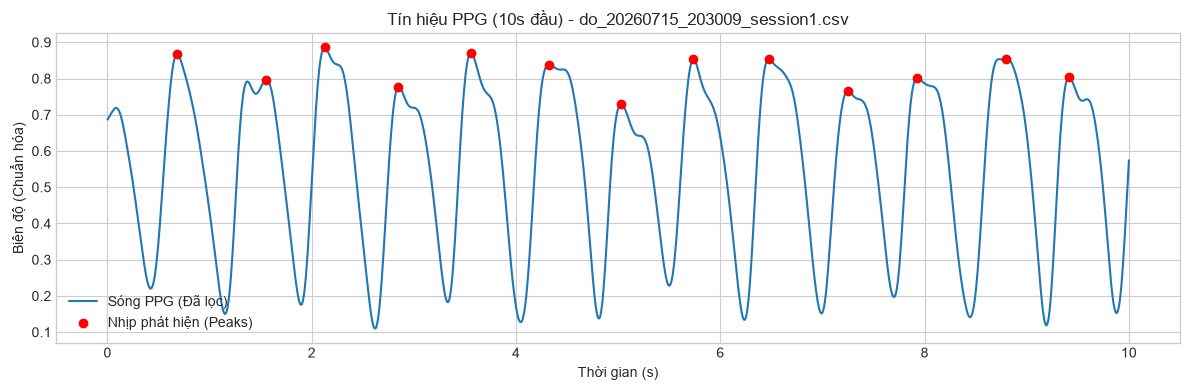

--- Đặc trưng trích xuất ---
Nhịp tim (HR): 81 BPM
Độ biến thiên (SDNN): 62.26 ms
Tỉ lệ LF/HF: 0.11

-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.

Đang xử lý: do_20260715_203139_session2.csv


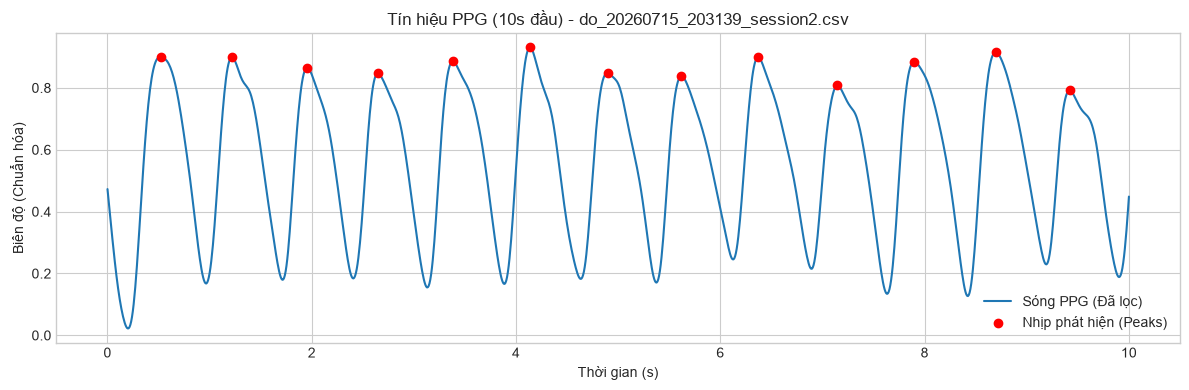

--- Đặc trưng trích xuất ---
Nhịp tim (HR): 82 BPM
Độ biến thiên (SDNN): 46.10 ms
Tỉ lệ LF/HF: 0.29

-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.

Đang xử lý: do_20260715_203309_session3.csv


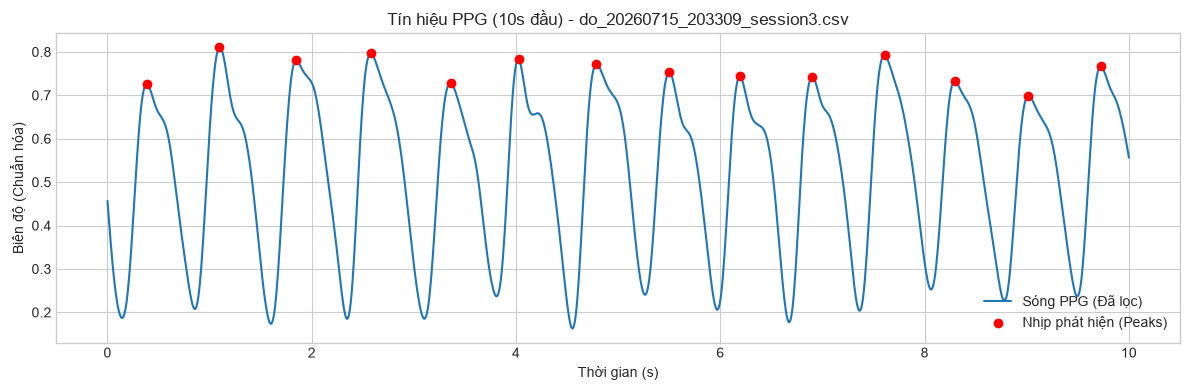

--- Đặc trưng trích xuất ---
Nhịp tim (HR): 86 BPM
Độ biến thiên (SDNN): 38.47 ms
Tỉ lệ LF/HF: 1.19

-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.

Đang xử lý: do_20260715_203439_session4.csv


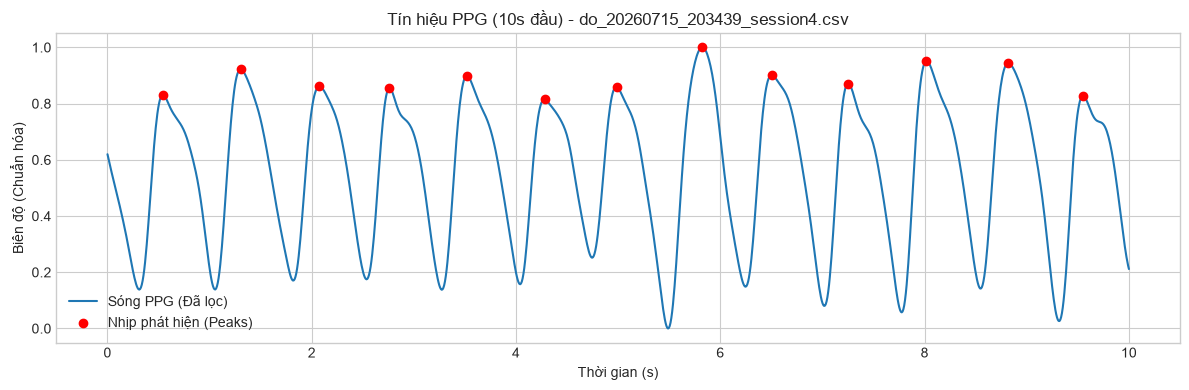

--- Đặc trưng trích xuất ---
Nhịp tim (HR): 81 BPM
Độ biến thiên (SDNN): 46.40 ms
Tỉ lệ LF/HF: 0.10

-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.

Đang xử lý: do_20260715_203609_session5.csv


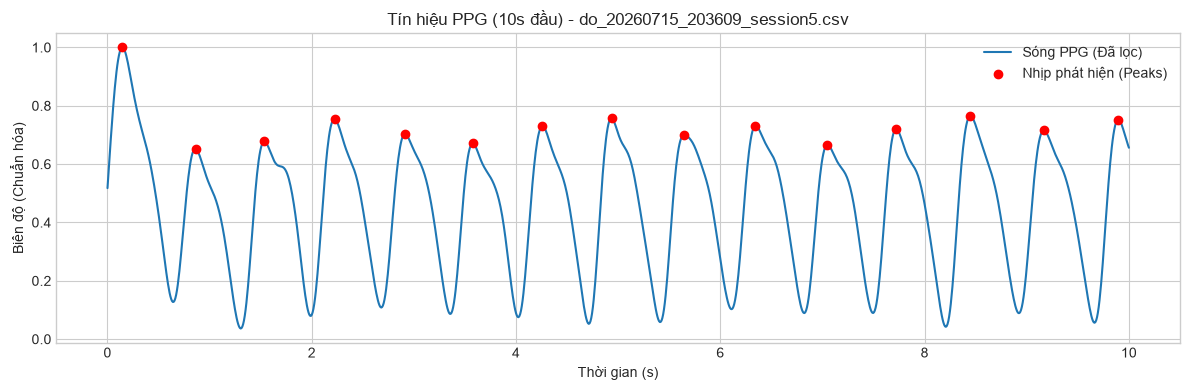

--- Đặc trưng trích xuất ---
Nhịp tim (HR): 85 BPM
Độ biến thiên (SDNN): 30.26 ms
Tỉ lệ LF/HF: 0.92

-> [✅ BÌNH THƯỜNG] Nhịp tim ổn định, không có dấu hiệu bất thường.


In [4]:
# Tải Model đã huấn luyện
model_path = MODELS_DIR / 'afib_rf_model.pkl'
if os.path.exists(model_path):
    print("Đã tải thành công Model AFib!")
    rf_model = joblib.load(model_path)
    
    # Chạy vòng lặp cho tất cả các file
    for file_path in csv_files:
        process_and_visualize(file_path, rf_model)
else:
    print(f"Không tìm thấy model tại {model_path}!")